<a href="https://colab.research.google.com/github/Laura-loaiza/Workshop-001/blob/main/SQL_KPIs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
import os
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


drive.mount('/content/drive')

# esta es la carpeta donde tengo todo el workshop
base_path = "/content/drive/My Drive/Colab Notebooks/workshop01"


CSV_PATH = os.path.join(base_path, "candidates.csv")
DW_PATH = os.path.join(base_path, "candidates_dw.db")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Paso 5: KPIs — todo consultado desde el DW

Cada grafico sale de un `pd.read_sql(query, conn)` contra `candidates_dw.db`.
Las mismas queries estan sueltas en `kpis_queries.sql`


### KPI 1: hires por tecnologia (pie)

In [3]:
conn = sqlite3.connect(DW_PATH)

query_tech = """
SELECT
    dt.technology,
    SUM(fc.hired) AS total_hired
FROM fact_application fc
JOIN dim_technology dt ON fc.id_technology = dt.id_technology
GROUP BY dt.technology
HAVING total_hired > 0
ORDER BY total_hired DESC;
"""

df_tech = pd.read_sql(query_tech, conn)
df_tech


,technology,total_hired
0,Development - CMS Backend,578
1,Sales,573
2,React Frontend,572
3,Client Success,558
4,Python Developer,551
5,DevOps,551
6,Adobe Experience Manager,549
7,Social Media Community Management,548
8,QA Manual,541
9,Java Backend,531


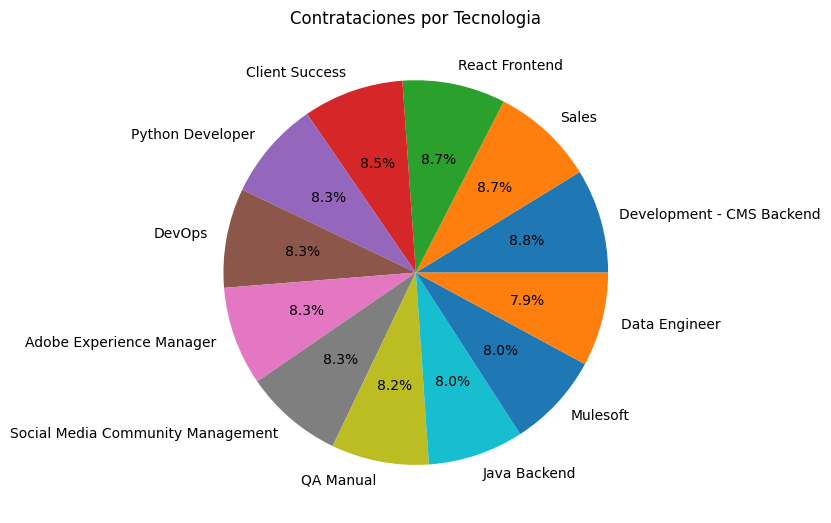

In [14]:
plt.figure(figsize=(8, 8))
plt.pie(df_tech["total_hired"], labels=df_tech["technology"], autopct="%1.1f%%")
plt.title("Contrataciones por Tecnologia")
plt.tight_layout()
plt.savefig(os.path.join(base_path, "kpi_hires_by_technology.png"))  # guardo la imagen en drive
plt.show()


### KPI 2: hires por año (barra horizontal)

In [5]:
query_year = """
SELECT
    dd.year,
    SUM(fc.hired) AS total_hired
FROM fact_application fc
JOIN dim_application_date dd ON fc.id_date = dd.id_date
GROUP BY dd.year
ORDER BY dd.year;
"""

df_year = pd.read_sql(query_year, conn)
df_year


,year,total_hired
0,2021,1094
1,2022,1351
2,2023,1336
3,2024,1295
4,2025,1336
5,2026,187


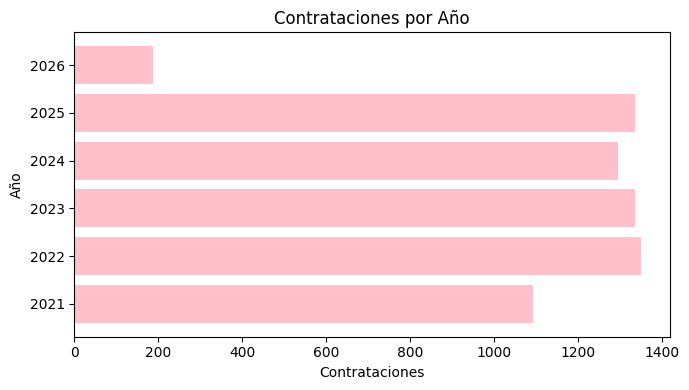

In [12]:
plt.figure(figsize=(7, 4))
plt.barh(df_year["year"].astype(str), df_year["total_hired"], color="pink")
plt.xlabel("Contrataciones")
plt.ylabel("Año")
plt.title("Contrataciones por Año")
plt.tight_layout()
plt.savefig(os.path.join(base_path, "kpi_hires_by_year.png"))
plt.show()


### KPI 3: hires por seniority (barra)

In [7]:
query_seniority = """
SELECT
    ds.seniority,
    SUM(fc.hired) AS total_hired
FROM fact_application fc
JOIN dim_seniority ds ON fc.id_seniority = ds.id_seniority
GROUP BY ds.seniority
ORDER BY total_hired DESC;
"""

df_seniority = pd.read_sql(query_seniority, conn)
df_seniority


,seniority,total_hired
0,Senior,927
1,Intern,921
2,Mid-Level,919
3,Manager,897
4,Lead,884
5,Junior,881
6,Trainee,846
7,Unknown,324


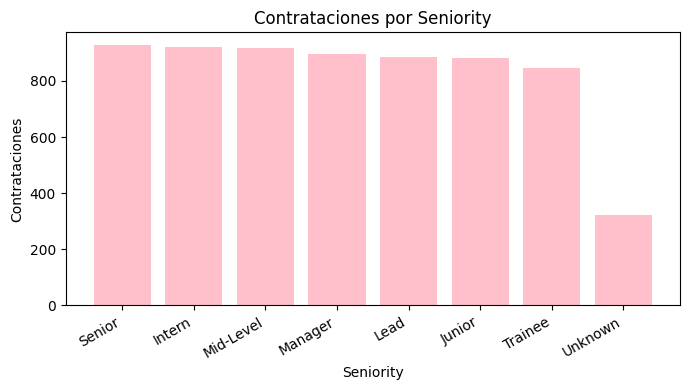

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(df_seniority["seniority"], df_seniority["total_hired"], color="pink")
plt.xlabel("Seniority")
plt.ylabel("Contrataciones")
plt.title("Contrataciones por Seniority")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(base_path, "kpi_hires_by_seniority.png"))
plt.show()


### KPI 4: hires por pais a traves de los años (USA, Brazil, Colombia, Ecuador)

Ojo: el pais ya no sale de una `dim_country`, ahora esta dentro de
`dim_candidate`. Por eso el join cambia un poco: uso `id_candidate`
para llegar hasta el pais.

In [10]:
query_country_year = """
SELECT
    dcand.country,
    dd.year,
    SUM(fa.hired) AS total_hired
FROM fact_application fa
JOIN dim_candidate dcand ON fa.id_candidate = dcand.id_candidate
JOIN dim_application_date dd ON fa.id_date = dd.id_date
WHERE dcand.country IN ('USA', 'Brazil', 'Colombia', 'Ecuador')
GROUP BY dcand.country, dd.year
ORDER BY dcand.country, dd.year;
"""

df_country_year = pd.read_sql(query_country_year, conn)
df_country_year


,country,year,total_hired
0,Brazil,2021,93
1,Brazil,2022,96
2,Brazil,2023,105
3,Brazil,2024,95
4,Brazil,2025,107
5,Brazil,2026,14
6,Colombia,2021,81
7,Colombia,2022,101
8,Colombia,2023,108
9,Colombia,2024,102


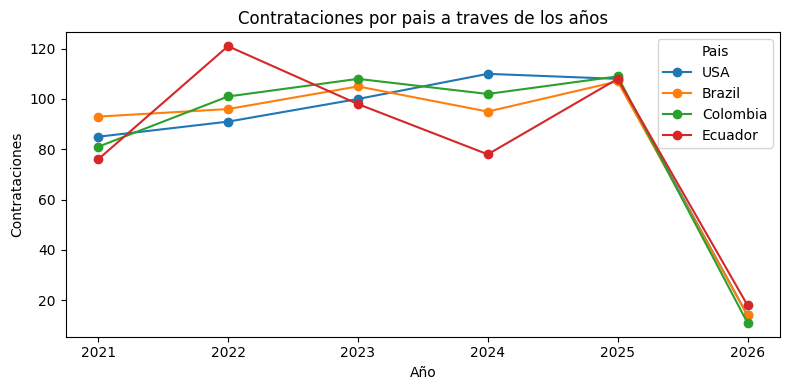

In [18]:
plt.figure(figsize=(8, 4))
for country in ["USA", "Brazil", "Colombia", "Ecuador"]:
    subset = df_country_year[df_country_year["country"] == country]
    plt.plot(subset["year"], subset["total_hired"], marker="o", label=country)

plt.xlabel("Año")
plt.ylabel("Contrataciones")
plt.title("Contrataciones por pais a traves de los años")
plt.legend(title="Pais")
plt.tight_layout()
plt.savefig(os.path.join(base_path, "kpi_hires_by_country_year.png"))
plt.show()


In [ ]:
conn.close()  # ya termine de consultar, cierro la conexion
